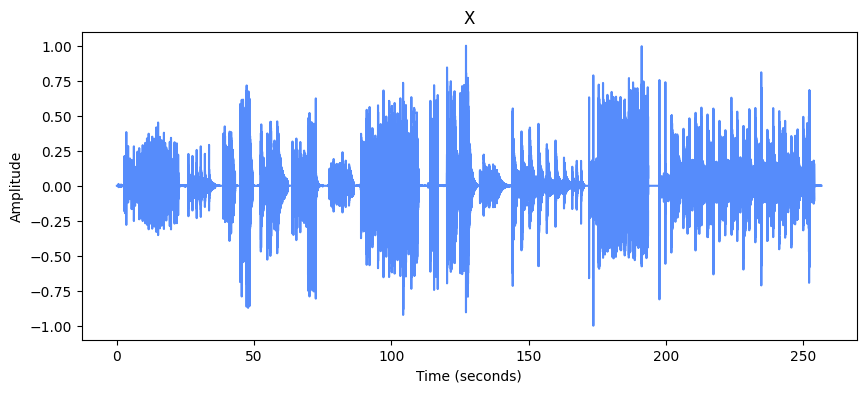

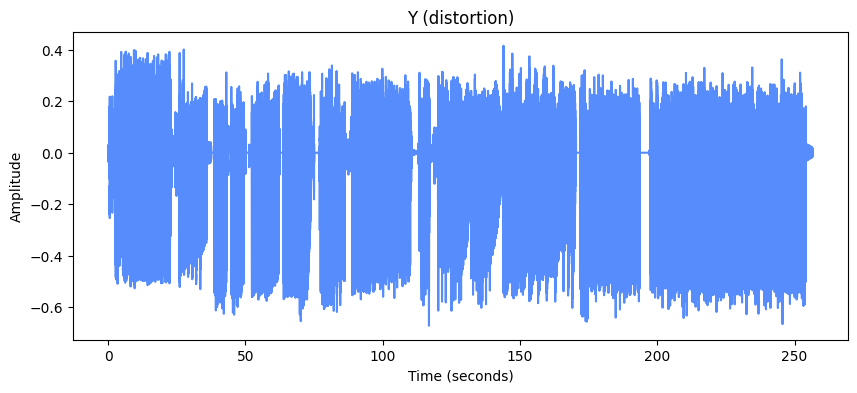

In [1]:

import matplotlib.pyplot as plt
import sounddevice as sd
import numpy as np
import torch
import torch.nn as nn
import librosa
import soundfile as sf
import time
import copy
import optuna
import json
import os

def load_wav(path, sr=22050):
    audio, sample_rate = librosa.load(path, sr=sr)  # mono by default
    return audio, sample_rate

def plot_waveform(audio, title, sr):
    time = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.figure(figsize=(10, 4))
    plt.plot(time, audio)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    #plt.xlim(10, 10.01)  # show only 0–1 seconds
    plt.ylabel("Amplitude")
    plt.show()

# Example
audio, sr = load_wav("Data/ML Guitar_ Initial_Data.wav")
plot_waveform(audio, "X", sr)
audio, sr = load_wav("Data/ML Guitar_Smadr_Target.wav")
plot_waveform(audio, "Y (distortion)", sr)

In [2]:


# =====================================================================
# Config  (fixed values; tunables live in the search space below)
# =====================================================================
class Config:
    sr          = 41500       # fixed: dataset is at this sample rate, and it divides nicely into blocks
    batch_size  = 128       # fixed: speed knob, not quality knob
    layers      = 1        # fixed: keep cheap
    block       = 512

    # ---- HP search / training budget ----
    n_trials        = 20       # Bayesian trials
    epochs_search   = 6        # short budget per trial (pruner kills bad ones early)
    steps_search    = 80       # fewer steps during search
    epochs_final    = 15       # longer run for the winning config
    steps_final     = 120
    patience        = 4        # early stopping for the final run

    study_name   = "distortion_gru"
    storage_path = "sqlite:///hp_study.db"     # persistent Optuna DB
    best_hp_path = "best_hp.json"              # human-readable best config

cfg = Config()


def load_wav(path, sr):
    audio, _ = librosa.load(path, sr=sr)
    return audio.astype(np.float32)

def prepare_data():
    print("Loading audio...")
    x = load_wav("Data/ML Guitar_ Initial_Data.wav", cfg.sr)
    y = load_wav("Data/ML Guitar_Smadr_Target.wav",  cfg.sr)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    print(f"  {n:,} samples  ({n/cfg.sr:.1f}s @ {cfg.sr} Hz)")

    split = int(0.8 * n)
    x_tr, x_te = x[:split], x[split:]
    y_tr, y_te = y[:split], y[split:]

    peak_x = np.max(np.abs(x_tr)) + 1e-8
    peak_y = np.max(np.abs(y_tr)) + 1e-8
    x_tr, x_te = x_tr / peak_x, x_te / peak_x
    y_tr, y_te = y_tr / peak_y, y_te / peak_y

    return (x_tr, y_tr, x_te, y_te), (peak_x, peak_y)

# =====================================================================
# Model
# =====================================================================
class DistortionGRU(nn.Module):
    def __init__(self, hidden, layers=cfg.layers):
        super().__init__()
        self.gru = nn.GRU(1, hidden, layers, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)

    def forward(self, x, state=None):
        out, state = self.gru(x, state)
        out = self.fc(out)
        return out, state

# =====================================================================
# Loss
# =====================================================================
def pre_emphasis(x, coeff):
    return x[:, 1:, :] - coeff * x[:, :-1, :]

def esr_loss(pred, target, coeff, eps=1e-8):
    pe_pred   = pre_emphasis(pred, coeff)
    pe_target = pre_emphasis(target, coeff)
    num = torch.sum((pe_pred - pe_target) ** 2)
    den = torch.sum(pe_target ** 2) + eps
    return num / den

# =====================================================================
# Batch sampler
# =====================================================================
def get_global_peaks_stream(x_tr, y_tr):
    peak_x = np.max(np.abs(x_tr)) + 1e-8
    peak_y = np.max(np.abs(y_tr)) + 1e-8
    return peak_x, peak_y

def sample_batch(x, y, seq_len, device):
    n = len(x)
    starts = torch.randint(0, n - seq_len, (cfg.batch_size,))
    offs   = torch.arange(seq_len)
    idx    = starts.unsqueeze(1) + offs.unsqueeze(0)
    xb = x[idx].unsqueeze(-1).to(device)
    yb = y[idx].unsqueeze(-1).to(device)
    return xb, yb

# =====================================================================
# Generic training loop (used by both search and final run)
#   - reports per-epoch test ESR
#   - if `trial` is given, supports Optuna pruning + early stopping
#   - returns (best_test_loss, best_state_dict)
# =====================================================================

def run_training(hp, data, device, epochs, steps,
                 trial=None, patience=None, verbose=False):
    x_tr, y_tr, x_te, y_te = data
    x_tr = torch.from_numpy(x_tr)
    y_tr = torch.from_numpy(y_tr)
    x_te = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    y_te = torch.from_numpy(y_te).unsqueeze(0).unsqueeze(-1).to(device)

    model = DistortionGRU(hidden=hp["hidden"]).to(device)
    opt = torch.optim.Adam(model.parameters(),
                           lr=hp["lr"], weight_decay=hp["weight_decay"])

    best_loss  = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        for _ in range(steps):
            xb, yb = sample_batch(x_tr, y_tr, hp["seq_len"], device)
            pred, _ = model(xb)
            warmup = hp["seq_len"] // 8
            loss = esr_loss(pred[:, warmup:], yb[:, warmup:], hp["pre_emph"])
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            pred, _ = model(x_te)
            test_loss = esr_loss(pred, y_te, hp["pre_emph"]).item()

        if test_loss < best_loss - 1e-4:
            best_loss  = test_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            flag = "  <-- best"
        else:
            wait += 1
            flag = ""

        if verbose:
            print(f"  Epoch {epoch+1:2d}/{epochs}  "
                  f"test ESR={test_loss:.4f}  ({time.time()-t0:.1f}s){flag}")

        # ---- Optuna pruning: report intermediate value, maybe kill trial ----
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        # ---- early stopping (final run only) ----
        if patience is not None and wait >= patience:
            if verbose:
                print(f"  Early stop. Best test ESR={best_loss:.4f}")
            break

    return best_loss, best_state

# =====================================================================
# Optuna objective
# =====================================================================
def make_objective(data, device):
    def objective(trial):
        hp = {
            "lr"          : trial.suggest_float("lr", 1e-3, 2e-2, log=True),
            "hidden"      : trial.suggest_categorical("hidden", [16, 24, 32, 48]),
            "seq_len"     : trial.suggest_categorical("seq_len", [128, 256, 512]),
            "pre_emph"    : trial.suggest_float("pre_emph", 0.7, 0.95),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        }
        best_loss, _ = run_training(
            hp, data, device,
            epochs=cfg.epochs_search,
            steps=cfg.steps_search,
            trial=trial,
        )
        return best_loss
    return objective


@torch.no_grad()
def bench(model, n=100):
    model = model.to("cpu").eval()
    x = torch.zeros(1, cfg.block, 1)
    h = None
    y, h = model(x, h)
    t0 = time.perf_counter()
    for _ in range(n):
        y, h = model(x, h)
    dt = (time.perf_counter() - t0) / n
    budget = cfg.block / cfg.sr * 1000
    print(f"\n{dt*1000:.2f} ms/block   (budget {budget:.1f} ms)   "
          f"{'OK' if dt*1000 < budget else 'TOO SLOW'}")

@torch.no_grad()
def render_test(model, data, peaks, device):
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks
    model.eval()
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    sf.write("predicted_distortion.wav", pred * peak_y, cfg.sr)
    sf.write("test_input_clean.wav",     x_te * peak_x, cfg.sr)
    sf.write("test_target_true.wav",     y_te * peak_y, cfg.sr)
    print("\nSaved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav")
def load_best_hp():
    """Load best HPs from JSON if it exists, else return None."""
    if not os.path.exists(cfg.best_hp_path):
        return None
    with open(cfg.best_hp_path) as f:
        record = json.load(f)
    print(f"Loaded best HPs from {cfg.best_hp_path} "
          f"(search ESR={record['search_esr']:.4f})")
    return record["params"]


In [3]:

# device = "mps" if torch.mps.is_available() else "cpu"
device = "cpu"
print(f"Device: {device}")
data, peaks = prepare_data()

# Toggle: force a fresh search even if best_hp.json exists.
FORCE_SEARCH = False

best = None if FORCE_SEARCH else load_best_hp()

Device: cpu
Loading audio...
  10,649,679 samples  (256.6s @ 41500 Hz)
Loaded best HPs from best_hp.json (search ESR=0.0053)


In [4]:

# ------------------------------------------------------------------
# Hyperparameter search (only if we don't already have best HPs)
# ------------------------------------------------------------------
if best is None:
    print(f"\n=== Hyperparameter search ===")

    study = optuna.create_study(
        study_name=cfg.study_name,
        storage=cfg.storage_path,          # persists to SQLite file
        load_if_exists=True,               # resume if DB already exists
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=0),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=2),
    )
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Only run more trials if we haven't reached the target count yet.
    done = len([t for t in study.trials
                if t.state in (optuna.trial.TrialState.COMPLETE,
                               optuna.trial.TrialState.PRUNED)])
    remaining = max(0, cfg.n_trials - done)
    if remaining > 0:
        print(f"  {done} trials already in DB, running {remaining} more "
              f"(target {cfg.n_trials})...")
        study.optimize(make_objective(data, device), n_trials=remaining,
                       show_progress_bar=True)
    else:
        print(f"  {done} trials already in DB (target {cfg.n_trials} reached). "
              f"Skipping search.")

    best = study.best_params
    print("\n=== Best hyperparameters ===")
    for k, v in best.items():
        print(f"  {k:13s}: {v}")
    print(f"  best search ESR: {study.best_value:.4f}")

    # ---------- Save best HPs to JSON ----------
    best_record = {
        "params"    : best,
        "search_esr": study.best_value,
        "n_trials"  : done + remaining,
        "fixed"     : {
            "sr"        : cfg.sr,
            "batch_size": cfg.batch_size,
            "layers"    : cfg.layers,
        },
    }
    with open(cfg.best_hp_path, "w") as f:
        json.dump(best_record, f, indent=2)
    print(f"  Saved best HPs -> {cfg.best_hp_path}")

In [5]:
# ------------------------------------------------------------------
# Final training with best HPs (longer run + early stopping)
# ------------------------------------------------------------------
print("\n=== Final training with best config ===")
hp = {
    "lr"          : best["lr"],
    "hidden"      : best["hidden"],
    "seq_len"     : best["seq_len"],
    "pre_emph"    : best["pre_emph"],
    "weight_decay": best["weight_decay"],
}
best_loss, best_state = run_training(
    hp, data, device,
    epochs=cfg.epochs_final, steps=cfg.steps_final,
    patience=cfg.patience, verbose=True,
)
print(f"\nFinal best test ESR = {best_loss:.4f}")

# rebuild model with winning architecture and load best weights
model = DistortionGRU(hidden=hp["hidden"]).to(device)
model.load_state_dict(best_state)

# ---------- Save trained model for zero-retrain reuse ----------
torch.save({
    "state_dict": best_state,
    "hp"        : hp,
    "peaks"     : peaks,
    "test_esr"  : best_loss,
}, "distortion_model.pt")
print("Saved trained model -> distortion_model.pt")


=== Final training with best config ===
  Epoch  1/15  test ESR=0.2513  (31.0s)  <-- best
  Epoch  2/15  test ESR=0.2359  (27.4s)  <-- best
  Epoch  3/15  test ESR=0.2013  (27.4s)  <-- best
  Epoch  4/15  test ESR=0.1849  (25.6s)  <-- best
  Epoch  5/15  test ESR=0.1681  (25.8s)  <-- best
  Epoch  6/15  test ESR=0.1696  (30.2s)
  Epoch  7/15  test ESR=0.1589  (25.3s)  <-- best
  Epoch  8/15  test ESR=0.1571  (25.0s)  <-- best
  Epoch  9/15  test ESR=0.1648  (25.4s)
  Epoch 10/15  test ESR=0.1573  (33.3s)
  Epoch 11/15  test ESR=0.1706  (27.9s)
  Epoch 12/15  test ESR=0.1551  (43.4s)  <-- best
  Epoch 13/15  test ESR=0.1811  (28.0s)
  Epoch 14/15  test ESR=0.1915  (35.9s)
  Epoch 15/15  test ESR=0.1642  (26.9s)

Final best test ESR = 0.1551
Saved trained model -> distortion_model.pt


In [6]:

# ---------- Outputs ----------
render_test(model, data, peaks, device)
bench(model)


Saved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav

4.11 ms/block   (budget 12.3 ms)   OK



================ Full test-set metrics ================
Test samples                  : 2,129,936 (51.3s)
ESR (whole test set)          : 0.0893
Worst 0.1% deviations (2,129 samples)
  mean |error| (normalized)   : 0.4091
  mean |error| (output scale) : 0.2696
Saved plot: segment_analysis.png


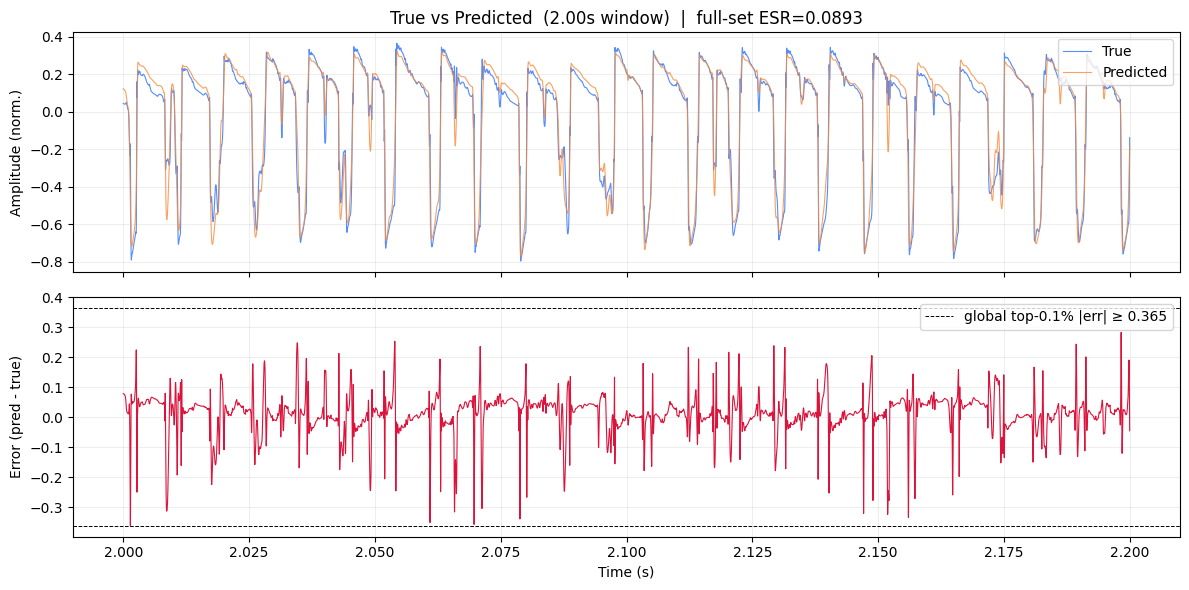

In [11]:
@torch.no_grad()
def analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=1.0):
    """
    Metrics  : computed over the ENTIRE test set.
    Plot     : only the window [plot_start_sec, plot_start_sec + plot_dur_sec].
    """
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks

    model.eval()

    # --- run the model over the whole test signal (stateful, causal) ---
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()          # normalized scale
    true = y_te                                   # normalized scale

    # ================== METRICS: full test set ==================
    err = pred - true
    esr = np.sum(err ** 2) / (np.sum(true ** 2) + 1e-8)

    abs_err = np.abs(err)
    n_top = max(1, int(0.001 * len(abs_err)))     # top 0.1%
    worst = np.sort(abs_err)[-n_top:]
    worst_mean = worst.mean()

    print("\n================ Full test-set metrics ================")
    print(f"Test samples                  : {len(true):,} "
          f"({len(true)/cfg.sr:.1f}s)")
    print(f"ESR (whole test set)          : {esr:.4f}")
    print(f"Worst 0.1% deviations ({n_top:,} samples)")
    print(f"  mean |error| (normalized)   : {worst_mean:.4f}")
    print(f"  mean |error| (output scale) : {worst_mean * peak_y:.4f}")
    print("=======================================================")

    # ================== PLOT: chosen window only ==================
    a = int(plot_start_sec * cfg.sr)
    b = a + int(plot_dur_sec * cfg.sr)
    b = min(b, len(true))
    a = max(0, min(a, b - 1))

    true_w = true[a:b]
    pred_w = pred[a:b]
    err_w  = err[a:b]
    t = np.arange(len(true_w)) / cfg.sr + a / cfg.sr   # absolute time (s)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(t, true_w, label="True",      linewidth=0.8)
    ax1.plot(t, pred_w, label="Predicted", linewidth=0.8, alpha=0.8)
    ax1.set_ylabel("Amplitude (norm.)")
    ax1.set_title(f"True vs Predicted  ({plot_start_sec:.2f}s window)  |  "
                  f"full-set ESR={esr:.4f}")
    ax1.legend(loc="upper right")
    ax1.grid(alpha=0.3)

    ax2.plot(t, err_w, color="crimson", linewidth=0.8)
    # threshold is taken from the WHOLE test set (so it's meaningful globally)
    thresh = worst.min()
    ax2.axhline( thresh, color="k", linestyle="--", linewidth=0.7,
                 label=f"global top-0.1% |err| ≥ {thresh:.3f}")
    ax2.axhline(-thresh, color="k", linestyle="--", linewidth=0.7)
    ax2.set_ylabel("Error (pred - true)")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc="upper right")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("segment_analysis.png", dpi=120)
    print("Saved plot: segment_analysis.png")
    plt.show()


analyze_segment(model, data, peaks, device, plot_start_sec=2.0, plot_dur_sec=0.2)


In [14]:
#import clean data and run the model over it, then save the output as a wav file for listening
@torch.no_grad()
def render_clean_input(model, audio, peaks, device):

    peak = np.max(audio) # use the same peaks for normalization
    model.eval()
    xt = torch.from_numpy(audio).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    sf.write("rendered_clean_input.wav", pred * peak, cfg.sr)
    print("\nSaved rendered_clean_input.wav")

data = librosa.load("Data/ML Guitar_ Initial_Data_Cut.wav", sr=cfg.sr)[0]
render_clean_input(model, data, peaks, device)


Saved rendered_clean_input.wav


In [8]:
# =====================================================================
# Streaming / bench / analysis  (unchanged logic, just take hp where needed)
# =====================================================================
def stream_audio(model, peaks, input_device=None, output_device=None):
    torch.set_num_threads(1)
    peak_x, peak_y = peaks
    in_scale  = 1.0 / peak_x
    out_scale = peak_y
    model = model.to("cpu").eval()

    with torch.no_grad():
        h = None
        for _ in range(5):
            _, h = model(torch.zeros(1, cfg.block, 1), h)

    state = {"h": None}

    @torch.no_grad()
    def callback(indata, outdata, frames, time_info, status):
        x = torch.from_numpy(indata[:, 0]).view(1, -1, 1) * in_scale
        y, state["h"] = model(x, state["h"])
        outdata[:, 0] = (y.view(-1) * out_scale).numpy()

    try:
        with sd.Stream(
            device=(input_device, output_device),
            channels=1, samplerate=cfg.sr, blocksize=cfg.block,
            latency="high", dtype="float32", callback=callback,
        ):
            print(f"\nLive @ {cfg.sr} Hz, block {cfg.block} "
                  f"({cfg.block/cfg.sr*1000:.1f} ms). Press Enter to stop.")
            input()
    except sd.PortAudioError as e:
        print(f"\n[Audio error] {e}")
        print(sd.query_devices())


In [12]:
# stream_audio(model, peaks, input_device=0, output_device=1)


Live @ 41500 Hz, block 512 (12.3 ms). Press Enter to stop.


In [10]:
#list input devices
print("\nAvailable audio devices:")
devices = sd.query_devices()
for i, dev in enumerate(devices):
    print(f"  {i:2d}: {dev['name']}  (input={dev['max_input_channels']}, output={dev['max_output_channels']})")



Available audio devices:
   0: MacBook Pro Microphone  (input=1, output=0)
   1: MacBook Pro Speakers  (input=0, output=2)
   2: Aggregate Device  (input=0, output=0)
   3: Multi-Output Device  (input=0, output=0)
